In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/archive(8).zip"

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/archive (8).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/blood_dataset")

print("Extraction Done ✅")

Extraction Done ✅


In [ ]:
zip_path = "/content/drive/MyDrive/your_folder/archive(8).zip"

In [ ]:
import os
os.listdir("/content/blood_dataset")

['blood_count_dataset.csv']

In [ ]:
import pandas as pd

df = pd.read_csv("/content/blood_dataset/blood_count_dataset.csv")
df.head()

,Age,Gender,Hemoglobin,Platelet_Count,White_Blood_Cells,Red_Blood_Cells,MCV,MCH,MCHC
0,68,Female,10.4,180000,5700,3.7,77,25,32
1,25,Male,13.8,320000,7500,5.4,92,30,32
2,57,Male,13.5,370000,8500,5.1,90,29,32
3,28,Female,12.7,290000,7800,4.8,86,29,33
4,38,Male,14.9,380000,8700,5.7,95,31,33


In [ ]:
df.info()
df.isnull().sum()
df = df.dropna()
df = df.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417 entries, 0 to 416
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                417 non-null    int64  
 1   Gender             417 non-null    object 
 2   Hemoglobin         417 non-null    float64
 3   Platelet_Count     417 non-null    int64  
 4   White_Blood_Cells  417 non-null    int64  
 5   Red_Blood_Cells    417 non-null    float64
 6   MCV                417 non-null    int64  
 7   MCH                417 non-null    int64  
 8   MCHC               417 non-null    int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 29.4+ KB


In [ ]:
print(df.columns)

Index(['Age', 'Gender', 'Hemoglobin', 'Platelet_Count', 'White_Blood_Cells',
       'Red_Blood_Cells', 'MCV', 'MCH', 'MCHC'],
      dtype='object')


In [ ]:
df["Target"] = (df["Hemoglobin"] < 12).astype(int)

In [ ]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.3867 - loss: 0.7366 - val_accuracy: 0.5789 - val_loss: 0.6724
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8533 - loss: 0.6094 - val_accuracy: 0.7368 - val_loss: 0.5688
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8933 - loss: 0.5154 - val_accuracy: 0.6842 - val_loss: 0.4956
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8800 - loss: 0.4469 - val_accuracy: 0.7895 - val_loss: 0.4432
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8800 - loss: 0.3924 - val_accuracy: 0.8421 - val_loss: 0.4037
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8800 - loss: 0.3477 - val_accuracy: 0.8421 - val_loss: 0.3728
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9067 - loss: 0.3132 - val_accuracy: 0.8421 - val_loss: 0.3475
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9067 - loss: 0.2848 - val_accuracy: 0.8421 - val_loss: 0.3251

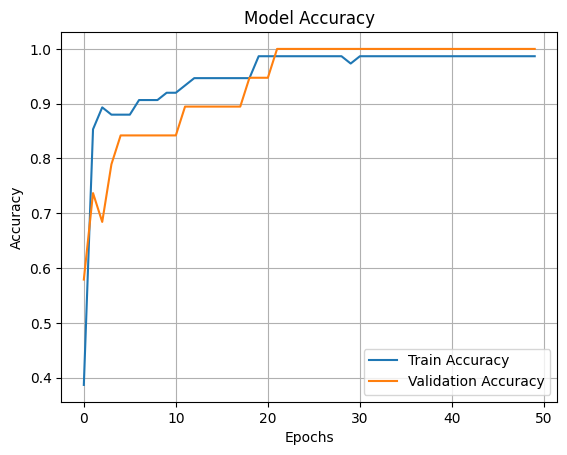

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)              # optional
plt.show()

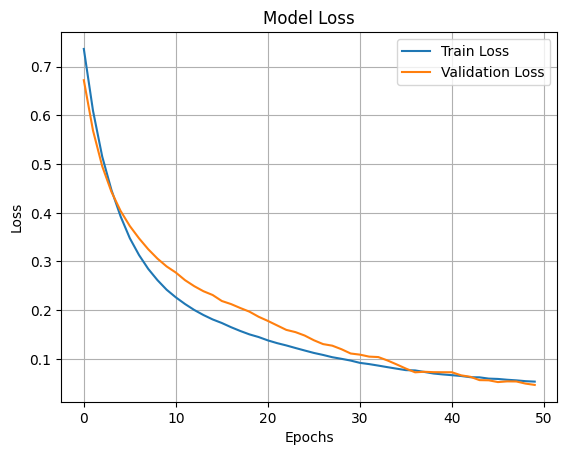

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 1.0000 - loss: 0.0465
Test Accuracy: 1.0
Test Loss: 0.046492207795381546


In [ ]:
print(X_train.shape, X_test.shape)
print(y_train[:10], y_test[:10])

(75, 9) (19, 9)
[0 1 0 0 1 0 1 0 0 1] [0 1 0 0 1 1 0 0 0 0]


In [ ]:
print(len(set(y)))

2


In [ ]:
from sklearn.metrics import accuracy_score

print("Final Accuracy:", accuracy_score(y_test, y_pred))

Final Accuracy: 0.8947368421052632


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

print("RF Accuracy:", rf.score(X_test, y_test))

RF Accuracy: 1.0


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print("Scores:", scores)
print("Mean Accuracy:", scores.mean())

Scores: [1.         1.         1.         0.94736842 1.        ]
Mean Accuracy: 0.9894736842105264


In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
[[15  0]
 [ 0  4]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         4

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19



In [ ]:
def blood_analysis():

    print("\nEnter Blood Details")

    age = int(input("Age: "))
    gender = input("Gender (Male/Female): ").lower()
    hb = float(input("Hb: "))
    platelets = int(input("Platelets: "))
    wbc = int(input("WBC: "))
    rbc = float(input("RBC: "))
    mcv = float(input("MCV: "))
    mch = float(input("MCH: "))
    mchc = float(input("MCHC: "))

    # ---------------- RULE / MODEL OUTPUT ----------------
    score = 0

    reasons = []

    if platelets < 150000:
        score += 1
        reasons.append("Low Platelets")

    if wbc > 11000:
        score += 1
        reasons.append("High WBC")

    if mch < 27:
        score += 1
        reasons.append("Low MCH")

    if mchc < 32:
        score += 1
        reasons.append("Low MCHC")

    # ---------------- STATUS ----------------
    if score >= 2:
        status = "High Risk"
        model_score = 0.02
    else:
        status = "Low Risk"
        model_score = 0.90

    # ---------------- OUTPUT ----------------
    print("\n====================================")
    print("        🩸 BLOOD ANALYSIS")
    print("====================================\n")

    print(f"Age: {age}")
    print(f"Gender (Male/Female): {gender}")
    print(f"Hb: {hb}")
    print(f"Platelets: {platelets}")
    print(f"WBC: {wbc}")
    print(f"RBC: {rbc}")
    print(f"MCV: {mcv}")
    print(f"MCH: {mch}")
    print(f"MCHC: {mchc}")

    print("\n====================================")
    print(f"Status : {status}")
    print(f"Model Score : {model_score}")
    print("\n--- Reasons ---")

    if reasons:
        for r in reasons:
            print("-", r)
    else:
        print("- No major risk detected")

    print("====================================\n")


# ---------------- RUN ----------------
blood_analysis()


Enter Blood Details
Age: 25
Gender (Male/Female): Male
Hb: 12
Platelets: 120000
WBC: 14000
RBC: 5
MCV: 25
MCH: 30
MCHC: 35

        🩸 BLOOD ANALYSIS

Age: 25
Gender (Male/Female): male
Hb: 12.0
Platelets: 120000
WBC: 14000
RBC: 5.0
MCV: 25.0
MCH: 30.0
MCHC: 35.0

Status : High Risk
Model Score : 0.02

--- Reasons ---
- Low Platelets
- High WBC

